In [30]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import cm, colors, rcParams, rc
rcParams.update({'axes.labelsize': 18,'font.size': 16 , 'font.family': "arial", "font.style": "normal", "font.weight": "bold", "axes.labelweight": "bold", "lines.linewidth": 2})#, 'font.serif': "cm"})
rc('xtick', labelsize=16) 
rc('ytick', labelsize=16)
from pint import UnitRegistry
from photonmover.utils.hdf5_utils import *
from photonmover.instruments.Lasers.SantecTSL570 import SantecTSL570
from photonmover.instruments.DAQ.NI_DAQ import NiDAQ
from scipy import io
from scipy.signal import find_peaks
import copy
import time

u = UnitRegistry()
Q_ = u.Quantity


# Initialize Instruments

In [32]:
# Create hdf5 file for data dump
# Create daq task for sweep 
    # - 1 AI for LIA output
    # - 1 AI for monitoring power
    # - 1 AI for Santec trig out to read wavelength (also triggers daq acquisition)
# Start laser step scan / sweep
# Use trig out (wavelength monitor) to start daq acquisition

data_dir = Path.home() / 'MIT Dropbox\Elise Uyehara\POE\wg_srs'

# Initialize instruments
daq = NiDAQ()
daq.initialize()
ch_wavmon = 'Dev1/ai20'  #Santec trigger output
ch_trig = ch_wavmon
ch_Vsrs = 'Dev1/ai0' # LIA output
ch_tap = 'Dev1/ai22' # Santec power mon
ai_channels = [ch_wavmon, ch_Vsrs, ch_tap]

santec = SantecTSL570()
santec.initialize()

Opening connnection to Santec TSL570 laser


b'SANTEC,TSL-570,24080031,0026.0026.0011'

# Function Definitions

In [33]:
def santec_spectra(sweep_params: dict, fname=None):
    # assumes instruments are already initialized
    
    # Save data if fname is not None
    if fname is not None:
        # Specify location of data save
        time_stamp = new_timestamp()
        spath = data_dir / Path(fname + '_' + time_stamp + '.h5')
        print("saving data to: ")
        print(spath)
        
    fsamp = (1 / (sweep_params["t_samp"])).to(u.Hz).m

    cycle_dwell = 0.8 * u.s # Measured for continuous two-way sweep
    t_sweep = sweep_params["num_sweeps"] * ((sweep_params["wav_stop"] - sweep_params["wav_start"]) / sweep_params["sweep_speed"])
    t_sweep += cycle_dwell * sweep_params["num_sweeps"]
    num_samp = int((fsamp * t_sweep).m)
    wav_res = (sweep_params["sweep_speed"] * sweep_params["t_lia"]).to(u.nm)
    
    # Configure Santec
    santec.set_sweep_mode(mode=1) #continuous sweep mode, two way
    santec.set_sweep_cont_speed(speed=sweep_params["sweep_speed"].to(u.nm/u.s).m)
    santec.set_sweep_cycles(cycles=sweep_params["num_sweeps"])
    santec.set_cycle_delay(delay=0) # Set cycle delay to 0s (since output periodic in wavelength)
    santec.set_sweep_wavelength_start(wav=sweep_params["wav_start"].to(u.nm).m)
    santec.set_sweep_wavelength_stop(wav=sweep_params["wav_stop"].to(u.nm).m)
    santec.set_trig_out_setting(mode=0) # Trig output periodic in wavelength
    santec.set_trig_out_step(wav_step=sweep_params["trig_interval"].to(u.nm).m) # Trig out every 1 nm
    santec.set_power(pow=20)
    santec.turn_on()
    
    # Create DAQ task
    daq.configure_anlgEdgeTrig_nsamp_acq(
        input_channels = ai_channels,
        trig_channel = ch_trig,
        trig_level = 1.5,
        num_points = num_samp,
        max_sampling_freq = fsamp,
        min_vals = [-10, -10, -10], 
        max_vals = [10, 10, 10]
    )
   
    # Print calculated sweep time
    print(f"sweep time: {t_sweep:3.2f}")
    start_time = time.time()
    end_time = start_time + t_sweep.m
    print(f"start time: {time.ctime(start_time):s}")
    print(f"stop time: {time.ctime(end_time):s}")
    print(f"wav_res: {wav_res}")
    
    # Start sweep
    daq.start_task() # Arms trigger to wait for trigger signal
    santec.set_sweep_status(state=1) #start Santec sweep
    daq.wait_task()
    raw_data = np.array(daq.read_data(num_samp))
    data_dict = {channel: data for channel, data in zip(ai_channels, raw_data)}
    offset = 0
    Vsrs = (data_dict[ch_Vsrs] / 10 + offset) * (sweep_params["sens_lia"]).to(u.V)
    sweep_data = {
        'Vsrs': Vsrs,
        'wavmon': data_dict[ch_wavmon] * u.V,
        'tap': data_dict[ch_tap] * u.V
    }
    ds_spec = sweep_data
    
    # Save sweep data to hdf5 and .mat
    if fname is not None:
        # sweep parameters 
        dump_hdf5(
            sweep_params,
            fpath=spath,
            open_mode='x',
        )
       
        dump_hdf5(sweep_data, spath)
        ds_spec = load_hdf5(fpath=spath)

        # Save data to .mat 
        mat_fname = str(spath)[:-2] + 'mat'
        file_dir = data_dir / Path(mat_fname)

        data = {'t_lia': ds_spec['t_lia'].to(u.s).m,
                't_samp': ds_spec['t_samp'].to(u.s).m,
                'sens_lia': ds_spec['sens_lia'].to(u.V).m,
                'wav_start': ds_spec['wav_start'].to(u.m).m,
                'wav_stop': ds_spec['wav_stop'].to(u.m).m,
                'sweep_speed': ds_spec['sweep_speed'].to(u.nm / u.s).m,
                'num_sweeps': ds_spec['num_sweeps'],
                'trig_interval': ds_spec['trig_interval'].to(u.nm).m,
                'fixed_wav': ds_spec['fixed_wav'].to(u.m).m,
                'Vsrs': ds_spec['Vsrs'].m,
                'wavmon': ds_spec['wavmon'].m,
                'tap': ds_spec['tap'].m
                }
        io.savemat(file_dir, data)
        
    return ds_spec

#----------------------------------------------------------------------------------
def oe_spectra(sweep_params: dict = {
        "wav_start":        1038 * u.nm, 
        "wav_stop":         1080 * u.nm, 
        "t_sweep":          60 * u.s,
        "t_lia":            30 * u.ms,
        "sens_lia":         300 * u.uV,
        "fixed_wav":        1375.0 * u.nm
},
        fname=None):
    """
    Acquires spectra by sweeping O-E land. So far unwrapping / plotting code only in Matlab
    Assumes instruments are already initialized
    - Make sure ch_wavmon is connected to OE-land wavelength wavmon photodiode!
    """
    
    # Save data if fname is not None
    if fname is not None:
        # Specify location of data save
        # sample_dir = resolve_sample_dir(sample_dir, data_dir=data_dir)
        # spath = new_path(name=fname, data_dir=sample_dir, ds_type='Sweep', extension='h5', timestamp=True)
        time_stamp = new_timestamp()
        spath = data_dir / Path(fname + '_' + time_stamp + '.h5')
        print("saving data to: ")
        print(spath)
        
    fsamp = (1 / (5 * sweep_params["t_lia"])).to(u.Hz)
    num_samp = int(sweep_params["t_sweep"].m / (1 / fsamp).m)
    
    # Create DAQ task
    daq.configure_nsampl_acq(
        input_channels=ai_channels,
        num_points=num_samp,
        max_sampling_freq=fsamp.m,
        min_vals=[-10, -10, -10],
        max_vals=[10, 10, 10]
    )
    
    # Print calculated sweep time
    sweep_time = sweep_params["t_sweep"]
    print(f"sweep time: {sweep_time:3.2f}")
    start_time = time.time()
    end_time = start_time + sweep_time.m
    print(f"start time: {time.ctime(start_time):s}")
    print(f"stop time: {time.ctime(end_time):s}")

    daq.start_task() # Arms trigger to wait for digital edge
    daq.wait_task()
    raw_data = np.array(daq.read_data(num_samp))
    data_dict = {channel: data for channel, data in zip(ai_channels, raw_data)}
    sweep_data = {
        'Vsrs': data_dict[ch_Vsrs]*u.V,
        'wavmon': data_dict[ch_wavmon]*u.V
    }
    
    # Save sweep data to hdf5 and .mat
    if fname is not None:
        # sweep parameters 
        dump_hdf5(
            sweep_params,
            fpath=spath,
            open_mode='x',
        )

        dump_hdf5(sweep_data, spath)
        ds_spec = load_hdf5(fpath=spath)

        # Save data to .mat 
        mat_fname = str(spath)[:-2] + 'mat'
        # file_dir = os.path.join(data_dir, sample_dir, mat_fname)
        file_dir = data_dir / Path(mat_fname)

        data = {'t_lia': ds_spec['t_lia'].to(u.s).m,
                'fsamp': fsamp.to(u.Hz).m,
                'sens_lia': ds_spec['sens_lia'].to(u.V).m,
                'wav_start': ds_spec['wav_start'].to(u.m).m,
                'wav_stop': ds_spec['wav_stop'].to(u.m).m,
                't_sweep': ds_spec['t_sweep'].to(u.s).m,
                'fixed_wav': ds_spec['fixed_wav'].to(u.m).m,
                'spec': ds_spec['Vsrs'].m,
                'wav_mon': ds_spec['wavmon'].m
                }
        io.savemat(file_dir, data)
        
    return ds_spec

#----------------------------------------------------------------------------------
def unwrap_Santec_sweep(fname, sample_dir=None, verbose=True):
    """
    Inputs:
        fname: list - filenames (.h5) of sweep data (assumes in data_dir unless sample_dir provided)
        sample_dir (optional) - subdirectory within data_dir of file location
        verbose - if True, generates 3 plots: (1) Vsrs vs wavelength, (2) Power Monitor vs wavelength, (3) Sampled wavelength from wavmon and linear fit vs index
    Outputs:
        santec_wav[0] - extracted wavelength from sweeps (first sweep only, but others should be identical) (1 x num_wavelengths)
        Vsrs_unwrap - wavelength-mapped and unwrapped Vsrs array (num_sweeps x num_wavelengths)
        tap_unwrap - wavelength-mapped and unwrapped tap array (num_sweeps x num_wavelengths)
    """

    if sample_dir is not None:
        fpath = data_dir / Path(sample_dir) / Path(fname)
    else: 
        fpath = data_dir / Path(fname)
    ds_spec = load_hdf5(fpath=fpath)

    # Find wavmon peak indices
    raw_pk_inds, _ = find_peaks(ds_spec["wavmon"], height=1.5, distance=100)
    num_pks = len(raw_pk_inds)
    num_sweeps = int(ds_spec["num_sweeps"])
    span = ds_spec["wav_stop"] - ds_spec["wav_start"]
    expected_num_pks = num_sweeps * (span.m / ds_spec["trig_interval"].m + 1)
    print(f"Num peaks: {num_pks}")
    print(f"Expected num peaks: {expected_num_pks}")

    # Create sampled 1d array of expected trigger pks
    trig_wavs = np.arange(ds_spec["wav_start"].m, ds_spec["wav_stop"].m + ds_spec["trig_interval"].m, ds_spec["trig_interval"].m)
    trig_concat = copy.deepcopy(trig_wavs)
    for rep in range(1, num_sweeps):
        if np.mod(rep, 2) != 0: #if odd
            next = trig_wavs[::-1]
        elif np.mod(rep, 2) == 0: #if even
            next = trig_wavs
        trig_concat = np.append(trig_concat, next)

    # Create full size 1d array of nans with wavmon peaks filled in
    wav_samp = np.full(shape=ds_spec["wavmon"].shape[0], fill_value=np.nan)
    for i, ind in enumerate(raw_pk_inds):
        wav_samp[ind] = trig_concat[i]

    #Reshape raw_pk_inds into num_sweeps x num_trig_pts array
    num_trig_pts = int(raw_pk_inds.shape[0] / num_sweeps) 
    pk_inds_arr = np.reshape(raw_pk_inds, (num_sweeps, num_trig_pts))

    # Create list of indices for start and end of each sweep
    start_ind = []
    end_ind = []
    for row in range(num_sweeps):
        start_ind.append(raw_pk_inds[row*num_trig_pts])
        end_ind.append(raw_pk_inds[(row+1)*num_trig_pts-1])
        
    # calculate mean length of sweep indices
    sweep_len = np.array(end_ind) - np.array(start_ind)
    mean_sweep_len = int(np.mean(sweep_len))

    # Create linear fit of wavelength
    pks_diff = np.diff(pk_inds_arr, axis=1)
    dind = np.mean(pks_diff) 
    dwav = ds_spec["trig_interval"].m
    
    #Create array (num_sweeps x mean_sweep_len) of estimated sweep indices
    ind_est = np.zeros((num_sweeps, mean_sweep_len), dtype=int)
    santec_wav = np.zeros((num_sweeps, mean_sweep_len))
    for row in range(num_sweeps):
        ind_est[row] = range(start_ind[row], start_ind[row]+ mean_sweep_len)
        #Create array of linear fit of wavelengths for each sweep, reversing odd sweeps
        if np.mod(row, 2) == 0:
            santec_wav[row] = ds_spec["wav_start"].m + (dwav / dind) * (ind_est[row] - ind_est[row][0])
        elif np.mod(row, 2) != 0: # odd sweep, reverse
            santec_wav[row] = ds_spec["wav_stop"].m - (dwav / dind) * (ind_est[row] - ind_est[row][0])
            
    # Parse Vsrs and tap data by ind_est
    Vsrs_unwrap = np.zeros((num_sweeps, mean_sweep_len))
    tap_unwrap = np.zeros((num_sweeps, mean_sweep_len))
    for row in range(num_sweeps):
        Vsrs_unwrap[row] = copy.deepcopy(ds_spec["Vsrs"][ind_est[row]])
        tap_unwrap[row] = copy.deepcopy(ds_spec["tap"][ind_est[row]])

    # Plot extracted wavelength and unwrapped sweep data
    if verbose: 
        # Check linear wavelength fit with sampled wavmon points
        fig, ax = plt.subplots(1,1, figsize=(4,3), tight_layout=True)
        ax.plot(range(wav_samp.shape[0]), wav_samp, marker='x')
        for row in range(ind_est.shape[0]):
            ax.plot(ind_est[row], santec_wav[row])
        ax.set_xlabel("Index")
        ax.set_ylabel("Wavelength (nm)")

        # Plot wavelength-mapped unwrapped Vsrs
        fig, ax = plt.subplots(1,1, figsize=(4,3), tight_layout=True)
        ax.plot(santec_wav[0], Vsrs_unwrap.T*1e6)
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("LIA Voltage (μV)") 
        
        # Plot wavelength-mapped unwrapped Power tap voltages
        fig, ax = plt.subplots(1,1, figsize=(4,3), tight_layout=True)
        ax.plot(santec_wav[0], tap_unwrap.T)
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Power Mon Voltage")
    
    return santec_wav[0]*u.nm, Vsrs_unwrap*u.V, tap_unwrap*u.V, ds_spec

#----------------------------------------------------------------------------------
def plot_Raman(fname, sample_dir=None, verbose=False, power_corr=True, label=None):#, cbar=None):
    """
    Unwraps and wavelength-maps Santec sweep using unwrap_Santec_sweep, then calculates Raman shift
    Inputs:
        - fname: list of file names to plot
        - verbose: if true, plots all intermediate plots
        - power_corr: if true, applies amplitude correction 
        - label: list of strings for plot legend
        - cbar: list of floats for colorbar (MUST BE IN ASCENDING ORDER) - only works for linear mapping
    """
    if verbose:
        fig, ax = plt.subplots(3,1, figsize=(4,8), tight_layout=True)
    else:
        fig1, ax1 = plt.subplots(1,1, figsize=(5,4), tight_layout=True)
        fig2, ax2 = plt.subplots(1,1, figsize=(5,4), tight_layout=True)
    
    cmap = cm.get_cmap("viridis", len(fname))

    for ind, name in enumerate(fname):
        print(name)
        santec_wav, Vsrs_unwrap, tap_unwrap, ds_spec = unwrap_Santec_sweep(fname=name, sample_dir=sample_dir, verbose=verbose)
        raman_shift = (1/(ds_spec["fixed_wav"].to(u.nm).m * u.nm) - 1/(santec_wav.to(u.nm).m * u.nm)).to(1/u.cm)
    
        # Normalize tap correction, apply power correction
        tap_norm = tap_unwrap / np.max(tap_unwrap)
        if power_corr:
            Vsrs_corr = Vsrs_unwrap / tap_norm
        else:
            Vsrs_corr = Vsrs_unwrap
            
        # Down sample for LIA integration time (discard every N_downsamp)
        N_downsamp = int(ds_spec["t_lia"] / ds_spec["t_samp"])
        print(f"N_downsamp: {N_downsamp}")
        raman_shift_downsamp = raman_shift.m[0:-1:N_downsamp]
        santec_wav_downsamp = santec_wav.m[0:-1:N_downsamp]
        Vsrs_corr_downsamp = Vsrs_corr.m[:, 0:-1:N_downsamp]
        Vsrs_mean = np.mean(Vsrs_corr_downsamp, axis=0) * u.V
        rs_res = raman_shift_downsamp[1] - raman_shift_downsamp[0]
        wav_res = santec_wav_downsamp[1] - santec_wav_downsamp[0]
        if verbose:
            ax[0].plot(raman_shift, Vsrs_unwrap.to(u.uV).T)
            ax[0].set_xlabel("Raman Shift ($cm^{-1}$)")
            ax[0].set_ylabel("LIA Voltage (μV)") 
            
            ax[1].plot(raman_shift, Vsrs_corr.to(u.uV).T)
            ax[1].set_xlabel("Raman Shift ($cm^{-1}$)")
            ax[1].set_ylabel("Power corrected (μV)") 
            
            ax[2].plot(raman_shift_downsamp, Vsrs_mean.to(u.uV))
            ax[2].set_xlabel("Raman Shift ($cm^{-1}$)")
            ax[2].set_ylabel("Vsrs Av. (μV)")
            print(f"Resolution: {rs_res: 2.2} (1/cm)")
        else:
            # Plot Vsrs_av over raman shift
            if label is not None:
                ax1.plot(raman_shift_downsamp, Vsrs_mean.to(u.uV), label=label[ind], color=cmap(ind))
                ax1.legend()
            else:
                ax1.plot(raman_shift_downsamp, Vsrs_mean.to(u.uV), color=cmap(ind))
            ax1.set_xlabel("Raman Shift ($cm^{-1}$)")
            ax1.set_ylabel("Vsrs Av. (μV)")
           
            print(f"Resolution: {rs_res: 2.2} (1/cm)")
            # Plot Vsrs_av over wavelength
            if label is not None:
                ax2.plot(santec_wav_downsamp, Vsrs_mean.to(u.uV), label=label[ind], color=cmap(ind))
                ax2.legend()
            else:
                ax2.plot(santec_wav_downsamp, Vsrs_mean.to(u.uV), color=cmap(ind))
            ax2.set_xlabel("Wavelength (nm)")
            ax2.set_ylabel("Vsrs Av. (μV)")
            print(f"Resolution: {wav_res: 2.2} (nm)")
            
    # if verbose is False and cbar is not None:
    #     sm = cm.ScalarMappable(cmap=cmap, norm=colors.Normalize(np.min(cbar), np.max(cbar)))
    #     fig1.colorbar(sm, ax=ax1, ticks=cbar)
    #     fig2.colorbar(sm, ax=ax2, ticks=cbar)
        
    return fig1, fig2

    

# Santec Sweep

In [39]:
# Acquire spectra by sweeping Santec
fname = "bcarot_W2_00_testwg2_OE127mW1080_Santec15.6mW_2"

sweep_params = {
        "wav_start":        1269 * u.nm, 
        "wav_stop":         1380 * u.nm, 
        "sweep_speed":      10 * u.nm / u.s,
        "trig_interval":    1 * u.nm,
        "num_sweeps":       3,
        "t_samp":           10 * u.us, 
        "t_lia":            30 * u.ms,
        "sens_lia":         300 * u.uV,
        "fixed_wav":        1079.11 * u.nm
}

ds_spec = santec_spectra(sweep_params, fname=fname)

saving data to: 
C:\Users\euyehara\MIT Dropbox\Elise Uyehara\POE\wg_srs\bcarot_W2_00_testwg2_OE127mW1080_Santec15.6mW_2_2026-03-31-00-44-45.h5
sweep time: 35.70 second
start time: Tue Mar 31 00:44:45 2026
stop time: Tue Mar 31 00:45:21 2026
wav_res: 0.3 nanometer
dumping item: wav_start
non-array, non-list item with units:
nanometer
dumping item: wav_stop
non-array, non-list item with units:
nanometer
dumping item: sweep_speed
non-array, non-list item with units:
nanometer / second
dumping item: trig_interval
non-array, non-list item with units:
nanometer
dumping item: num_sweeps
non-array, non-list item without units
dumping item: t_samp
non-array, non-list item with units:
microsecond
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: sens_lia
non-array, non-list item with units:
microvolt
dumping item: fixed_wav
non-array, non-list item with units:
nanometer
dumping item: Vsrs
dumping item: wavmon
dumping item: tap
loading file: bcarot_W2_00_testwg2_O

In [ ]:
# Acquire spectra by sweeping OE-land
fname = "DMSO_sweepOE78mW_Santec13mW1375nm"
sweep_params = {
        "wav_start":        1260 * u.nm, 
        "wav_stop":         1380 * u.nm, 
        "t_sweep":          60 * u.s,
        "t_lia":            30 * u.ms,
        "sens_lia":         300 * u.uV,
        "fixed_wav":        1375.0 * u.nm
}
ds_spec = oe_spectra(sweep_params=sweep_params, fname=fname)


In [134]:
santec.close()
daq.close()

Closing connnection to Santec TSL570 laser


# Plotting Sweeps

loading file: bcarot_W2_00_testwg2_OE127mW1080_Santec15.6mW_2_2026-03-31-00-44-45.h5
importing Vsrs...
importing tap...
importing wavmon...
importing attr fixed_wav...
nanometer
importing attr fixed_wav_units...
importing attr num_sweeps...
importing attr sens_lia...
microvolt
importing attr sens_lia_units...
importing attr sweep_speed...
nanometer / second
importing attr sweep_speed_units...
importing attr t_lia...
millisecond
importing attr t_lia_units...
importing attr t_samp...
microsecond
importing attr t_samp_units...
importing attr trig_interval...
nanometer
importing attr trig_interval_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
Num peaks: 336
Expected num peaks: 336.0


C:\Users\euyehara\AppData\Local\Temp\ipykernel_16380\3131898699.py:263: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  Vsrs_unwrap[row] = copy.deepcopy(ds_spec["Vsrs"][ind_est[row]])
C:\Users\euyehara\AppData\Local\Temp\ipykernel_16380\3131898699.py:264: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  tap_unwrap[row] = copy.deepcopy(ds_spec["tap"][ind_est[row]])


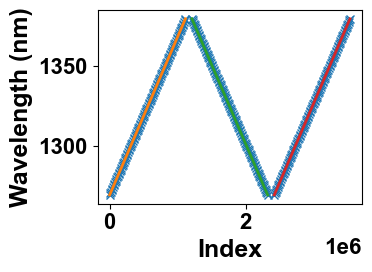

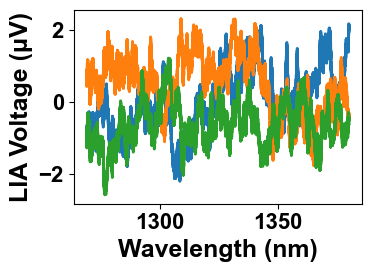

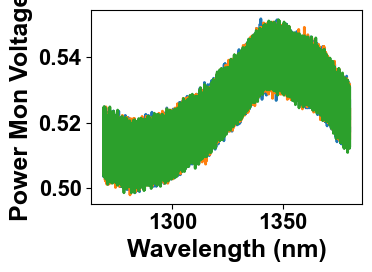

In [42]:
%matplotlib inline

fname = "bcarot_W2_00_testwg2_OE127mW1080_Santec15.6mW_2_2026-03-31-00-44-45.h5"
# fname = "bcarot_W2_00_testwg2_OE127mW1080_Santec15.6mW_2026-03-31-00-43-26.h5"
# fname = "W2_00_testwg2_OE127mW1040_Santec15.6mW_2026-03-31-00-35-35.h5"
# fname = "W2_00_testwg2_OE103mW1040_Santec15.7mW_2026-03-29-01-34-17.h5"
# fname = "W2_00_testwg2_OE103mW1040_Santec15.7mW_2026-03-29-01-38-19.h5"
# fname = "dmso_W2_00_testwg2_OE103mW1040_Santec15.7mW_2026-03-29-01-51-26.h5"
# fname = "dmso_W2_00_testwg2_OE103mW1040_Santec15.7mW_3_2026-03-29-02-12-54.h5"
# fname = "dmso_W2_00_testwg2_OE103mW1040_Santec15.7mW_2_2026-03-29-02-11-42.h5"
# fname = "dmso_W2_00_testwg2_OE103mW1040_Santec15.7mW_4_2026-03-29-02-22-12.h5"

# fname = "dmso_OE89mW1040_Santec13mW_R_3_2026-03-04-22-53-39.h5"
# fname = "dmso_OE89mW1040_Santec13mW_R_2_2026-03-04-22-49-18.h5"
# fname = "dmso_OE89mW1038_Santec13mW_R_2026-03-04-22-42-54.h5"
# fname = "dmso_OE89mW1064_Santec13mW_R_2026-03-04-22-40-08.h5"
# fname = "bareSiN_OE89mW1071_Santec13mW_R_2026-03-04-22-31-05.h5"
# fname = "bareSiN_OE89mW1064.26_Santec13mW_R_2026-03-04-22-24-51.h5"
# fname = "bareSiN_OE89mW1050.88_Santec13mW_R_2026-03-04-22-07-21.h5"
# fname = "bareSiN_OE89mW1044_Santec13mW_R_2_2026-03-04-21-55-51.h5"
# fname = "bareSiN_OE89mW1044_Santec13mW_R_2026-03-04-21-53-28.h5"
# fname = "bareSiN_OE89mW1038_R_2026-03-04-21-48-22.h5"
# fname = "bareSiN_OE89mW1038Santec13mW_R_2026-03-04-21-45-30.h5"
# fname = "bareSiN_OE89mW1039_Santec13mW_R_2026-03-04-21-35-14.h5"
# fname = "bareSiN_Santec13mW_R_2026-03-04-21-37-47.h5"

sample_dir = "W2_00_TZPolish_3-29-26"
santec_wav, Vsrs_unwrap, tap_unwrap, ds_spec = unwrap_Santec_sweep(fname, sample_dir=sample_dir)

bcarot_W2_00_testwg2_OE127mW1080_Santec15.6mW_2_2026-03-31-00-44-45.h5
loading file: bcarot_W2_00_testwg2_OE127mW1080_Santec15.6mW_2_2026-03-31-00-44-45.h5
importing Vsrs...
importing tap...
importing wavmon...
importing attr fixed_wav...
nanometer
importing attr fixed_wav_units...
importing attr num_sweeps...
importing attr sens_lia...
microvolt
importing attr sens_lia_units...
importing attr sweep_speed...
nanometer / second
importing attr sweep_speed_units...
importing attr t_lia...
millisecond
importing attr t_lia_units...
importing attr t_samp...
microsecond
importing attr t_samp_units...
importing attr trig_interval...
nanometer
importing attr trig_interval_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
Num peaks: 336
Expected num peaks: 336.0


C:\Users\euyehara\AppData\Local\Temp\ipykernel_16380\3131898699.py:263: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  Vsrs_unwrap[row] = copy.deepcopy(ds_spec["Vsrs"][ind_est[row]])
C:\Users\euyehara\AppData\Local\Temp\ipykernel_16380\3131898699.py:264: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  tap_unwrap[row] = copy.deepcopy(ds_spec["tap"][ind_est[row]])


N_downsamp: 3000
Resolution:  1.9 (1/cm)
Resolution:  0.3 (nm)
bcarot_W2_00_testwg2_OE127mW1080_Santec15.6mW_2026-03-31-00-43-26.h5
loading file: bcarot_W2_00_testwg2_OE127mW1080_Santec15.6mW_2026-03-31-00-43-26.h5
importing Vsrs...
importing tap...
importing wavmon...
importing attr fixed_wav...
nanometer
importing attr fixed_wav_units...
importing attr num_sweeps...
importing attr sens_lia...
microvolt
importing attr sens_lia_units...
importing attr sweep_speed...
nanometer / second
importing attr sweep_speed_units...
importing attr t_lia...
millisecond
importing attr t_lia_units...
importing attr t_samp...
microsecond
importing attr t_samp_units...
importing attr trig_interval...
nanometer
importing attr trig_interval_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
Num peaks: 336
Expected num peaks: 336.0
N_downsamp: 3000
Resolution:  1.9 (1/cm)
Resolution:  0.3 (nm)


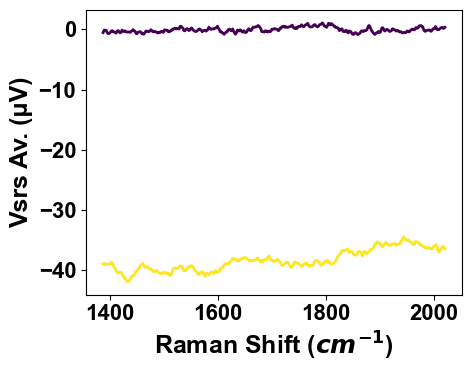

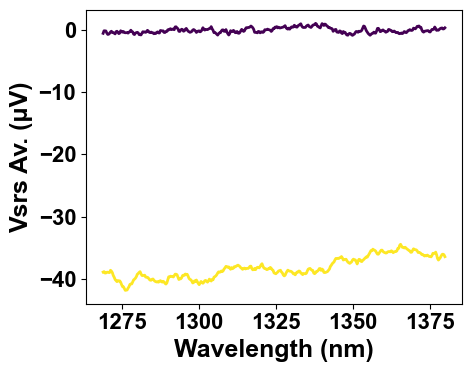

In [46]:
# fname = "bareSiN_OE78mW_Santec12mW_2026-03-04-00-14-40.h5"
# fname="DMSO_OE78mW_Santec12mW_0_2026-03-04-00-46-19.h5"
# sample_dir = 'DMSO_3-4-26'
%matplotlib inline
fname = [
    "bcarot_W2_00_testwg2_OE127mW1080_Santec15.6mW_2_2026-03-31-00-44-45.h5",
    "bcarot_W2_00_testwg2_OE127mW1080_Santec15.6mW_2026-03-31-00-43-26.h5"
    # "W2_00_testwg2_OE127mW1040_Santec15.6mW_2026-03-31-00-35-35.h5"
    # "dmso_W2_00_testwg2_OE103mW1040_Santec15.7mW_2026-03-29-01-51-26.h5",
        #  "dmso_W2_00_testwg2_OE103mW1040_Santec15.7mW_2_2026-03-29-02-11-42.h5",
        #  "dmso_W2_00_testwg2_OE103mW1040_Santec15.7mW_2_2026-03-29-02-11-42.h5"
    # "W2_00_testwg2_OE103mW1040_Santec15.7mW_2026-03-29-01-34-17.h5",
        #  "W2_00_testwg2_OE103mW1040_Santec15.7mW_2026-03-29-01-38-19.h5"
        ]

# fname = [
    # "dmso_OE89mW1040_Santec13mW_R_2_2026-03-04-22-49-18.h5",
    # "dmso_OE89mW1038_Santec13mW_R_2026-03-04-22-42-54.h5",
    # "dmso_OE89mW1040_Santec13mW_R_2026-03-04-22-47-34.h5",
    # "dmso_OE89mW1064_Santec13mW_R_2026-03-04-22-40-08.h5",
    
    # "bareSiN_OE89mW1038Santec13mW_R_2026-03-04-21-45-30.h5",
    # "bareSiN_OE89mW1039_Santec13mW_R_2026-03-04-21-35-14.h5",
    # "bareSiN_OE89mW1041.89_Santec13mW_R_2026-03-04-22-00-15.h5",
    # "bareSiN_OE89mW1044_Santec13mW_R_2_2026-03-04-21-55-51.h5",
    # "bareSiN_OE89mW1050.88_Santec13mW_R_2026-03-04-22-07-21.h5",
    # "bareSiN_OE89mW1064.26_Santec13mW_R_2026-03-04-22-24-51.h5",
    # "bareSiN_OE89mW1071_Santec13mW_R_2026-03-04-22-31-05.h5",
    
    # "bareSiN_OE89mW1044_Santec13mW_R_2026-03-04-21-53-28.h5",
    # "bareSiN_OE89mW1038_R_2026-03-04-21-48-22.h5",
    # "bareSiN_Santec13mW_R_2026-03-04-21-37-47.h5",
    # ]
label = None #["1038", "1040", "1064"] # ["1038.43", "1039.5", "1041.89", "1043.8", "1050.88", "1064.26", "1071.0"]
cbar = np.array(label).astype(float)
fig1, fig2 = plot_Raman(fname, sample_dir=sample_dir, verbose=False, power_corr=False, label=label)

# Untested Functions

In [ ]:
#----------------------------------------------------------------------------------
def unwrap_OE_sweep(fname, sample_dir=None, verbose=True):
    # Unwrap O-E land sweep - untested, converted from Matlab
    if sample_dir is not None:
        fpath = data_dir / Path(sample_dir) / Path(fname)
    else: 
        fpath = data_dir / Path(fname)
    ds_spec = load_hdf5(fpath=fpath)
    
    #O-Eland sweep parameters
    rate = 3.548 * u.nm / u.s # O-E land tuning rate
    t_decel = 0.8 * u.s # Time to remove at turning points of sweep
    filt_wav = 1064 * u.nm #Location of bandpass filter
    wav_start = ds_spec["wav_start"]
    wav_stop = ds_spec["wav_stop"]
    dt = 1/ds_spec["fsamp"] #daq sampling period[s]
    dwav = rate * dt #wavelength quantization error [nm]
    N_decel = ds_spec["fsamp"] * t_decel #Number of points at endpoints in nonlinear regime 
    spec = ds_spec["Vsrs"]
    t = np.arange(1, ds_spec["wavmon"].shape[0], 1) / ds_spec["fsamp"] #[s]


    # Identify peak locations (time) in wavelength monitor data
    pk_inds, _ = find_peaks(ds_spec["wavmon"], height=0.04, distance=50)

    # Identify midway point between peaks as turning points of sweeps
    midpeak_inds = pk_inds + np.round(np.append(np.diff(pk_inds), pk_inds[-2] - pk_inds[-3]) / 2) 
    if midpeak_inds[-1] > t.shape[0]: # check if full sweep after last peak
        midpeak_inds = midpeak_inds[:-1] # If last element exceeds length of t, discard
    
    wav_t = np.zeros(ds_spec["wavmon"].shape)

    fpos = lambda t, t_delay: rate * (t - t_delay) + wav_start
    fneg = lambda t, t_delay: - rate * (t - t_delay) + wav_stop
    tp_delay = lambda t_filt1: t_filt1 - 1/rate * (filt_wav - wav_start)
    tn_delay = lambda t_filt1: t_filt1 + 1/rate * (filt_wav - wav_stop)
    pspec_ind = lambda start_ind, stop_ind: np.arange(start_ind, stop_ind+1, 1)
    nspec_ind = lambda start_ind, stop_ind: np.arange(stop_ind, start_ind-1, -1)

    #Basic case with no full sweeps before or after first/last turn points)
    spec_num = midpeak_inds.shape[0] - 1 #number of turn points - 1
    start_ind = midpeak_inds[0] #start from first turn point
    stop_ind = midpeak_inds[-1] #stop at last turn point
    loop_start = 0 
    loop_stop = midpeak_inds.shape[0] - 1

    #Fluctuation in segment length from quantization error - take min length
    spec_len = np.min(np.diff(midpeak_inds))

    #Determine if full sweep exists before and after first/last turn-around points
    if midpeak_inds[0] >= spec_len: #full sweep exists before first turn point
        spec_num = spec_num + 1
        start_ind = start_ind - spec_len
        loop_start = 1
    if ds_spec["Vsrs"].shape[0] - midpeak_inds[-1] >= spec_len: # full sweep exists after last turn point
        spec_num = spec_num + 1
        stop_ind = stop_ind + spec_len
        loop_stop = loop_stop + 1

    #Initialize spec_arr
    spec_arr = np.zeros((spec_num, spec_len))

    #Determine if first full sweep positive or negative
    dt10 = t[pk_inds[1]] - t[pk_inds[0]]
    dt21 = t[pk_inds[2]] - t[pk_inds[1]]

    #Define conditions of positive or negative initial wavelength slope of first full sweep
    if dt10 > dt21: # Start wavelength slope negative (decreasing)
        t_d = tn_delay
        topp_d = tp_delay
        f = fneg
        fopp = fpos

        if midpeak_inds[0] >= spec_len: #full sweep exists before first turn point
            spec_ind = pspec_ind # Since wav_t decreasing with increasing t
            oppspec_ind = nspec_ind
#             fprintf("Decreasing, full initial sweep")
        else: #start from next sweep (positive)
            spec_ind = nspec_ind
            oppspec_ind = pspec_ind
#             fprintf("Decreasing, incomplete initial sweep")
        
    elif dt10 < dt21: #Start wavelength slope positive (increasing)
        t_d = tp_delay
        topp_d = tn_delay
        f = fpos
        fopp = fneg

        if midpeak_inds[0] >= spec_len: #full sweep exists before first turn point
            spec_ind = pspec_ind
            oppspec_ind = nspec_ind
#             fprintf("Increasing, full initial sweep")
        else: #start from next sweep (negative)
            spec_ind = nspec_ind
            oppspec_ind = pspec_ind
#             fprintf("Increasing, incomplete initial sweep")

    #Find delay time 
    t_delay = t_d(t[pk_inds[0]])
    topp_delay = topp_d(t[pk_inds[0]])

    # Find first segment of wavelength sweep before first midpeak_ind (if exists)
    if midpeak_inds[0] >= spec_len:
        wav_t[0:midpeak_inds[0]] = f(t[0:midpeak_inds[0]], t_delay)
        spec_arr[0,:] = spec[spec_ind[start_ind, midpeak_inds[0]-1]]

    #Iterate through midpeak_inds
    #reverse first segment on all odd-to-even indexed segments,
    #repeat slope for all even-to-odd indexed segments
    #create array of spectra segments - reverse those on negative wavelength sweeps
    for i in range(loop_stop):
        t_delay = t_delay + (t[pk_inds[i+1]] - t[pk_inds[i]])
        topp_delay = topp_delay + (t[pk_inds[i+1]] - t[pk_inds[i]])
        if np.mod(i,2): #Odd-index beginning segments - opposite slope
            wav_t[midpeak_inds[i]:midpeak_inds[i+1]] = fopp(t[midpeak_inds[i]:midpeak_inds[i+1]], topp_delay)
            spec_arr[i+loop_start,:] = spec[oppspec_ind(midpeak_inds[i], midpeak_inds[i]+spec_len - 1)]
        else: #Even-index beginning segments - same slope
            wav_t[midpeak_inds[i]:midpeak_inds[i+1]] = f(t[midpeak_inds[i]:midpeak_inds[i+1]], t_delay)
            spec_arr[i+loop_start,:] = spec[spec_ind[midpeak_inds[i], midpeak_inds[i] + spec_len - 1]]
    
    #Find starting wavelength
    wavelength = wav_t[start_ind : start_ind + spec_len-1]  

    #Truncate portions in nonlinear deceleration sweep regime
    wavelength = wavelength[N_decel:-N_decel]
    spec_arr = spec_arr[:, N_decel:-N_decel]
    
    #Calculate Raman Shift
    if ds_spec["fixed_wav"] < np.max(wavelength):
        pump_wav = ds_spec["fixed_wav"] #[nm]
        stokes_wav = wavelength #[nm]
    elif ds_spec["fixed_wav"] >= max(wavelength):
        pump_wav = wavelength  #[nm]
        stokes_wav = ds_spec["fixed_wav"]  #[nm]
   
    raman_shift = (1./pump_wav - 1./stokes_wav).to(1/u.cm) #[cm^-1]
    
    #Order wavenumber indices in ascending order
    if raman_shift[1] < raman_shift[0]:
        wavelength = wavelength[::-1]
        raman_shift = raman_shift[::-1]
        spec_arr = spec_arr[:,::-1]
    
    if verbose:
        #Plot raw data
        fig, ax = plt.subplots(2,1, figsize=(4,8), tight_layout=True)
        ax[0].plot(t, ds_spec["wavmon"])
        ax[0].set_ylabel("Voltage (V)")
        ax[0].title("Wavelength Monitor")
        ax[1].plot(t, spec)
        ax[1].set_xlabel("Time (s)")
        ax[1].set_ylabel("Voltage (V)")
        ax[1].title("Raw Spectra")

        # Plot unwrapped spectra (all reps) vs wavelength
        fig, ax = plt.subplots(1,1, figsize=(4,6), tight_layout=True)
        ax.plot(wavelength, spec_arr)
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Voltage (V)")

    return raman_shift, spec_arr 
